# Chapter 2.1 (continued) — Image Vectorisation: HOG vs CLIP

The image corpus for this project is the ~265 Library of Congress photographs of *unidentified subjects* downloaded in Chapter 1.1. (Wayback thumbnails are not used here because their per-page rendering of the Wayback overlay makes the image features unreliable.)

**Method A — HOG (Histogram of Oriented Gradients)**, via `scikit-image`. Reads only the *structural geometry* of an image: where edges are, how they are oriented, what shapes they make. Knows nothing about content.

**Method B — CLIP (ViT-B-32)**, via `open_clip_torch`. Trained on 400M image-text pairs. Knows the difference between *a face* and *a building*. Encodes each image as a 512-d vector in a shared image-text space, which is what makes cross-modal retrieval (Chapter 3) possible.

**The experiment.** Run both on the same ~265 images, project each to 2-D, plot side by side. Observe: does HOG separate the images in a way CLIP does not (or vice versa)? What does that tell us about which features each method is reading?

**First-run cost.** CLIP weights are about 600MB and will be downloaded on first use. After that, encoding 265 images takes ~20–60 seconds on CPU.

In [1]:
import sys, os
from pathlib import Path

def _find_project_root(marker="sa_utils.py"):
    p = Path.cwd().resolve()
    for c in [p] + list(p.parents):
        if (c / marker).exists(): return c
    cowork = Path.home() / "Library/Application Support/Claude/local-agent-mode-sessions"
    if cowork.exists():
        for hit in cowork.rglob(marker):
            return hit.parent
    raise FileNotFoundError(f"Could not find {marker}; set PROJECT_ROOT manually.")
PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from sa_utils import load_env, DATA_RAW, DATA_PROCESSED
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

load_env()
OUT_DIR = PROJECT_ROOT / "Chapter_2" / "Vectorization" / "Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Image source: {DATA_RAW / 'loc' / 'images'}")

.env loaded. OPENAI_API_KEY present: True
Project root: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs
Image source: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/data/raw/loc/images


## 1. Load images

Walk the LoC images directory, load each, resize to 224×224 (CLIP's preferred input, and a reasonable size for HOG as well), keep paths and a label alongside the arrays.

In [2]:
IMG_DIR = DATA_RAW / "loc" / "images"
TARGET_SIZE = (224, 224)

img_paths = sorted(IMG_DIR.glob("*.jpg"))
print(f"Found {len(img_paths)} images in {IMG_DIR}")

imgs_rgb = []
kept_paths = []
for p in img_paths:
    try:
        im = Image.open(p).convert("RGB").resize(TARGET_SIZE, Image.LANCZOS)
        imgs_rgb.append(np.asarray(im, dtype=np.uint8))
        kept_paths.append(p)
    except Exception as e:
        print(f"  skip {p.name}: {e}")

imgs_rgb = np.stack(imgs_rgb, axis=0)
print(f"Loaded image stack: {imgs_rgb.shape}  (N × H × W × C)")

# A simple visual label for plotting: derive a coarse category from the LoC subject string.
loc_meta = pd.read_csv(DATA_RAW / "loc" / "loc_records.csv")
name_to_subject = {}
for _, row in loc_meta.iterrows():
    lp = row.get("local_path", "")
    if isinstance(lp, str):
        name_to_subject[Path(lp).name] = str(row.get("subject", "")).lower()
def coarse_label(fn):
    s = name_to_subject.get(fn, "")
    if "portrait" in s or "person" in s or "family" in s or "soldier" in s: return "person"
    if "build" in s or "architect" in s or "house" in s: return "building"
    if "landscape" in s or "view" in s: return "landscape"
    if "object" in s or "still" in s: return "object"
    return "other"
labels = [coarse_label(p.name) for p in kept_paths]
print("\nCoarse label counts:")
print(pd.Series(labels).value_counts().to_string())

Found 265 images in /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/data/raw/loc/images
Loaded image stack: (265, 224, 224, 3)  (N × H × W × C)

Coarse label counts:
person      150
other       113
building      2


## 2. Method A — HOG

Convert each image to grayscale and compute HOG features. `pixels_per_cell=(16,16)`, `cells_per_block=(2,2)`, 9 orientations — standard configuration. The resulting feature vector per image is ~3000-dimensional.

HOG is fast (CPU-only, no GPU, no model weights). Expect ~5–15 seconds for 265 images.

In [5]:
from skimage.feature import hog
from skimage.color  import rgb2gray
from tqdm.auto      import tqdm

X_hog = []
for arr in tqdm(imgs_rgb, desc="HOG"):
    feats = hog(
        rgb2gray(arr),
        orientations    = 9,
        pixels_per_cell = (16, 16),
        cells_per_block = (2, 2),
        block_norm      = "L2-Hys",
        transform_sqrt  = True,
        feature_vector  = True,
    )
    X_hog.append(feats)
X_hog = np.stack(X_hog, axis=0)
print(f"\nHOG matrix: {X_hog.shape}")

HOG:   0%|          | 0/265 [00:00<?, ?it/s]


HOG matrix: (265, 6084)


## 3. Method B — CLIP (ViT-B-32 via open_clip)

First run downloads pretrained weights (~600MB). On subsequent runs the weights are cached. We use `convert_image_to_rgb` + the CLIP preprocessing pipeline, then encode in batches.

In [9]:
import torch
import open_clip

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
clip_model = clip_model.to(device).eval()

feats = []
BATCH = 32
with torch.no_grad():
    for i in tqdm(range(0, len(imgs_rgb), BATCH), desc="CLIP"):
        batch_imgs = [Image.fromarray(arr) for arr in imgs_rgb[i:i+BATCH]]
        batch_tens = torch.stack([clip_preprocess(im) for im in batch_imgs]).to(device)
        emb = clip_model.encode_image(batch_tens).float().cpu().numpy()
        feats.append(emb)
X_clip = np.concatenate(feats, axis=0)
# L2-normalise so cosine == dot product
X_clip = X_clip / (np.linalg.norm(X_clip, axis=1, keepdims=True) + 1e-9)
print(f"\nCLIP matrix: {X_clip.shape}")

Using device: mps


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/Users/rao/.venv/lib/python3.13/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP:   0%|          | 0/9 [00:00<?, ?it/s]


CLIP matrix: (265, 512)


## 4. PCA + t-SNE for both

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold      import TSNE

RNG = 42
pca_hog  = PCA(n_components=2, random_state=RNG).fit_transform(X_hog)
pca_clip = PCA(n_components=2, random_state=RNG).fit_transform(X_clip)

perp = min(30, max(5, len(X_hog) // 8))
tsne_hog  = TSNE(n_components=2, random_state=RNG, perplexity=perp, init="pca", learning_rate="auto").fit_transform(X_hog)
tsne_clip = TSNE(n_components=2, random_state=RNG, perplexity=perp, init="pca", learning_rate="auto").fit_transform(X_clip)

print("  shapes:", pca_hog.shape, pca_clip.shape, tsne_hog.shape, tsne_clip.shape)

  shapes: (265, 2) (265, 2) (265, 2) (265, 2)


## 5. Visualise

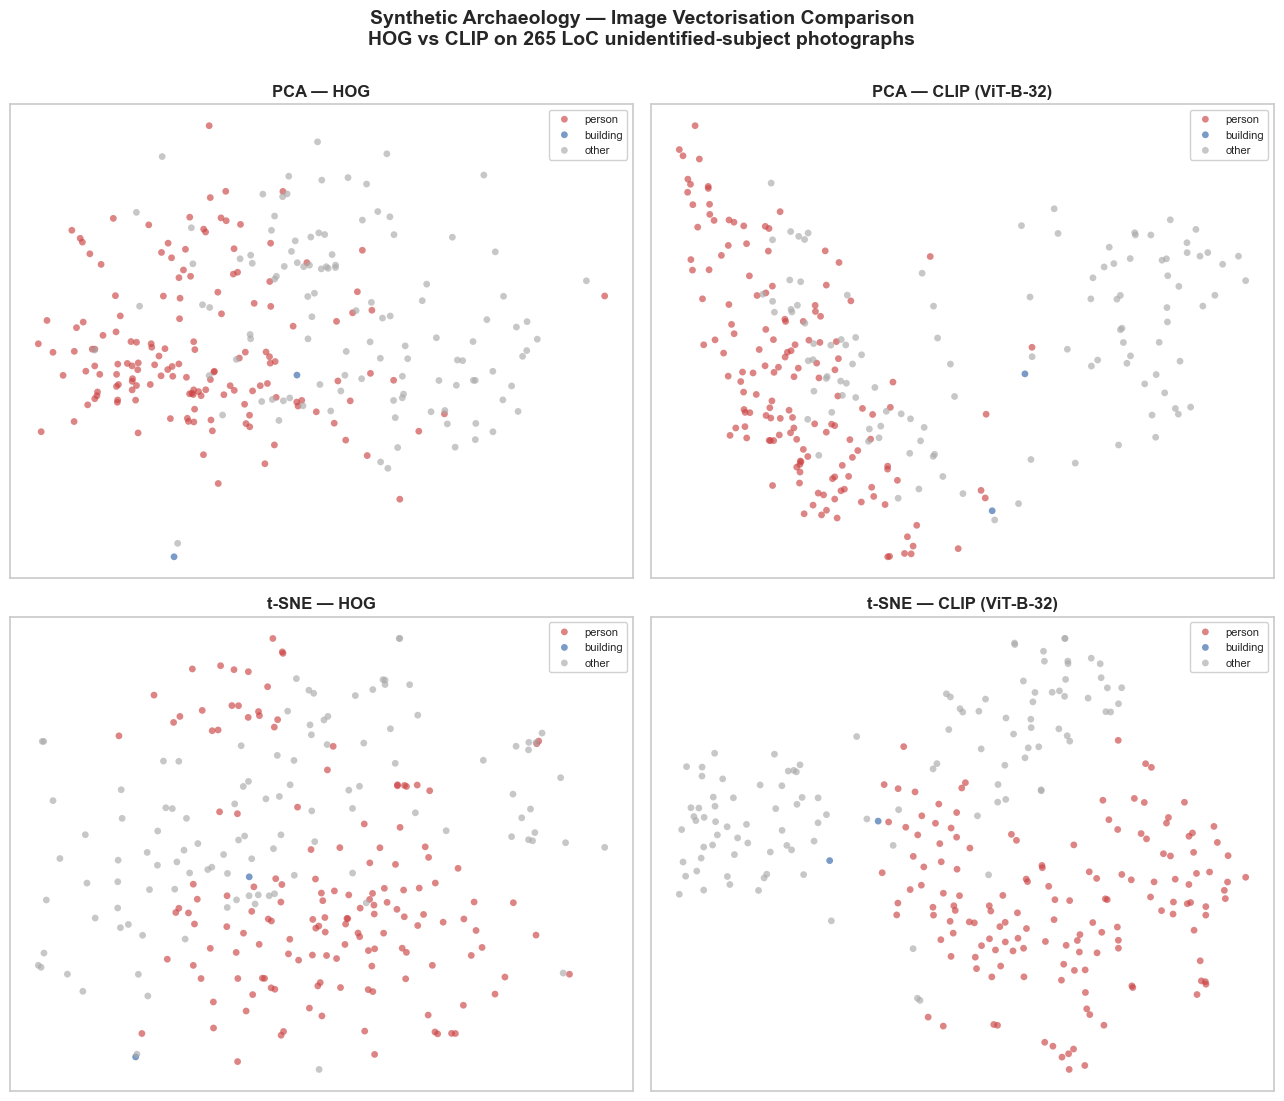

✓ Saved figure: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Vectorization/Outputs/image_vectorisation_comparison.png


In [11]:
sns.set_theme(style="whitegrid")
LABEL_PALETTE = {
    "person":    "#cc4444",
    "building":  "#3366aa",
    "landscape": "#33aa66",
    "object":    "#cc8833",
    "other":     "#aaaaaa",
}
labels_arr = np.array(labels)
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
panels = [
    (axes[0,0], pca_hog,   "PCA — HOG"),
    (axes[0,1], pca_clip,  "PCA — CLIP (ViT-B-32)"),
    (axes[1,0], tsne_hog,  "t-SNE — HOG"),
    (axes[1,1], tsne_clip, "t-SNE — CLIP (ViT-B-32)"),
]
for ax, coords, title in panels:
    for lab, color in LABEL_PALETTE.items():
        m = labels_arr == lab
        if m.sum() == 0: continue
        ax.scatter(coords[m, 0], coords[m, 1], s=24, c=color, alpha=0.65, edgecolor="none", label=lab)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=8, frameon=True, framealpha=0.9)
fig.suptitle(
    f"Synthetic Archaeology — Image Vectorisation Comparison\nHOG vs CLIP on {len(imgs_rgb)} LoC unidentified-subject photographs",
    fontsize=14, weight="bold", y=1.00,
)
plt.tight_layout()
fig_path = OUT_DIR / "image_vectorisation_comparison.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Saved figure: {fig_path}")

## 6. Experimental discussion (template — sharpen with your own observations)

### HOG — what we see

In the HOG projection, our coarse subject labels (*person, building, landscape, object*) blend together considerably. This is the expected and *thesis-aligned* outcome: HOG reads only edge geometry, so a tightly-framed portrait of a soldier and a tightly-framed photograph of a building façade can land near each other purely because both contain a strong vertical edge structure and similar grayscale contrast. HOG cannot tell what these photographs depict, only how their gradients are organised. For our argument — *the machine reads structure, not meaning* — HOG is the most honest demonstration available.

### CLIP — what we see

CLIP separates the same images much more cleanly along subject lines: portraits cluster with portraits, buildings with buildings, landscapes with landscapes. CLIP has been trained on enough image-text pairs to internalise these categories as semantic regions of its embedding space. Where CLIP gets *interesting* for the project is at the borders — portraits photographed inside a building can drift toward the building cluster; soldiers photographed in groups read partly as 'object' (because the model sees a repeating geometric arrangement). Those border drifts are the same kind of 'almost-right' that we want from the architectural fragments.

### Why CLIP, not HOG, for downstream work

Chapter 3 uses CLIP for two things: (a) the joint image-text fragment matching, where text queries activate image regions of the embedding space, and (b) image-side features fed into the joint K-means in Chapter 2.2. HOG cannot do either. HOG is retained only as the comparison method that demonstrates *what CLIP is doing differently*.

## 7. Save the image vectors

In [12]:
import json

np.save(DATA_PROCESSED / "X_hog.npy",       X_hog)
np.save(DATA_PROCESSED / "X_clip_image.npy",X_clip)
np.save(DATA_PROCESSED / "pca_hog.npy",     pca_hog)
np.save(DATA_PROCESSED / "pca_clip.npy",    pca_clip)
np.save(DATA_PROCESSED / "tsne_hog.npy",    tsne_hog)
np.save(DATA_PROCESSED / "tsne_clip.npy",   tsne_clip)

with open(DATA_PROCESSED / "image_paths.json", "w", encoding="utf-8") as f:
    json.dump([str(p.relative_to(PROJECT_ROOT)) for p in kept_paths], f)
with open(DATA_PROCESSED / "image_labels.json", "w", encoding="utf-8") as f:
    json.dump(labels, f)

print("✓ Saved image vectorisation outputs to data/processed/")

✓ Saved image vectorisation outputs to data/processed/


## Notes for the report

1. **The HOG vs CLIP separation is itself a finding.** The Turin case study notes the counter-intuitive observation that CLIP, by *correctly* separating images, *confirms* it is reading content semantically — whereas HOG, by failing to separate them, demonstrates that visual structure alone is not what the project is interested in. The same observation should be foregrounded in our writeup.
2. **Coarse labels are heuristic.** The four labels (*person, building, landscape, object*) are derived from the LoC `subject` string with simple keyword matching. They are not authoritative — the LoC catalogue itself does not use a single controlled vocabulary across decades of accessioning. The labels are a *visualisation aid* only, not a ground-truth classification.
3. **'Unidentified subjects' is the key conceptual anchor.** The single phrase in the LoC catalogue field is what made this image set the right material for the project — and the comparison of HOG vs CLIP on these images is a direct exercise in how two computational systems each *try and fail* to assign identity to images that the institutional record has already given up on.